# Dataset statistics

Metrics of the four downloaded datasets, computed on the files as downloaded (no preprocessing):
number of rows and features, benign/malicious split, attack categories, feature names,
`head()` / `info()` / `describe()` and feature distributions.

Every loader returns a DataFrame holding the features plus two columns:
- `attack_cat`: attack category (multi-class label)
- `label`: 0 = benign, 1 = malicious

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# works both when started from the repo root and from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = ROOT / "dataset"

summary = {}

Alcune cose notevoli emerse dai grafici e da describe():

- Il 37% delle righe di UNSW-NB15 è duplicato (94.928 su 257.673).
- CTU-13: come categoria d'attacco uso la famiglia di botnet presa dal nome del file (1-Neris-… diventa Botnet-Neris), altrimenti ci sarebbe solo "Botnet". Il traffico Background (95,6% delle righe) lo conto come benigno, come fa il tuo preprocessing, ma nelle categorie resta separato da Normal.
- Nell'output di describe() di CIC-IDS2017 compaiono due RuntimeWarning: nascono dal calcolo della deviazione standard sulle colonne con valori infiniti e non indicano un errore.
- Otto feature di CIC-IDS2017 hanno sempre lo stesso valore: Bwd PSH Flags, Bwd URG Flags e le 6 colonne *Bulk*. Negli istogrammi appaiono come una sola barra. C'è anche la colonna ripetuta Fwd Header Length.1, e tutte queste spiegano perché lo split preprocessato ha meno feature.
- Ci sono valori negativi senza senso fisico: Flow Duration arriva a −9,2·10¹¹ in CSE-CIC-IDS2018, e Fwd Header Length e min_seg_size_forward sono negativi in CIC-IDS2017. Sono artefatti noti di CICFlowMeter, lo strumento che ha estratto le feature.

## Loaders

In [2]:
def load_unsw():
    """Official training + testing partition, the one used by the experiments."""
    files = ["UNSW_NB15_training-set.csv", "UNSW_NB15_testing-set.csv"]
    df = pd.concat([pd.read_csv(DATASET_DIR / "unsw-nb15" / f) for f in files], ignore_index=True)
    return df.drop(columns=["id"])  # sequential row number, not a feature


def load_ctu13():
    """13 captures (scenarios), each one infected by a single botnet family."""
    frames = []
    for f in sorted((DATASET_DIR / "ctu13" / "raw").glob("*.parquet")):
        part = pd.read_parquet(f).drop(columns=["Family"])  # capture date, not a feature
        family = f.name.split("-")[1]                         # '1-Neris-20110810...' -> 'Neris'
        raw = part.pop("label").str.lower()                   # e.g. 'flow=From-Botnet-V42-UDP-DNS'
        part["attack_cat"] = np.select(
            [raw.str.contains("botnet"), raw.str.contains("normal")],
            [f"Botnet-{family}", "Normal"], default="Background",
        )
        frames.append(part)
    df = pd.concat(frames, ignore_index=True)
    # Background has no ground truth: counted as benign, like the preprocessing does
    df["label"] = df["attack_cat"].str.startswith("Botnet").astype(int)
    return df


def load_cicids2017():
    """8 daily CSV captures."""
    files = sorted((DATASET_DIR / "cicids2017" / "raw").glob("*.csv"))
    # latin1: some files hold bytes that are not valid UTF-8
    df = pd.concat([pd.read_csv(f, encoding="latin1", low_memory=False) for f in files], ignore_index=True)
    df.columns = df.columns.str.strip()  # names come padded with spaces
    df["attack_cat"] = df.pop("Label").str.replace("ï¿½", "-")  # broken dash in 'Web Attack - XSS'
    df["label"] = (df["attack_cat"] != "BENIGN").astype(int)
    return df


def load_csecicids2018():
    """10 daily captures."""
    files = sorted((DATASET_DIR / "csecicids2018" / "raw").glob("*.parquet"))
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df["attack_cat"] = df.pop("Label").astype(str)
    df["label"] = (df["attack_cat"] != "Benign").astype(int)
    return df

## Analysis functions

In [3]:
def counts(s):
    """Absolute and percentage frequency of every value of a column."""
    return pd.DataFrame({"count": s.value_counts(),
                         "%": (100 * s.value_counts(normalize=True)).round(3)})


def report(name, df):
    """Prints the metrics and the pandas overviews, returns a summary row."""
    features = df.drop(columns=["attack_cat", "label"])
    numeric = features.select_dtypes("number")

    print(f"{name}: {len(df):,} rows, {features.shape[1]} features\n")

    print("Benign vs malicious:")
    display(counts(df["label"].map({0: "Benign", 1: "Malicious"})))

    print("Attack categories:")
    display(counts(df["attack_cat"]))

    print(f"Feature names ({features.shape[1]}):\n{list(features.columns)}\n")

    display(df.head())
    df.info(show_counts=True)
    display(numeric.describe().T)
    if numeric.shape[1] < features.shape[1]:  # categorical (string) features
        display(features.describe(exclude="number").T)

    malicious = df["label"].mean()
    return {
        "rows": len(df),
        "features": features.shape[1],
        "benign %": round(100 * (1 - malicious), 3),
        "malicious %": round(100 * malicious, 3),
        "attack categories": df.loc[df["label"] == 1, "attack_cat"].nunique(),
        "missing values": int(features.isna().sum().sum()),
        "infinite values": int(np.isinf(numeric).sum().sum()),
        "duplicate rows": int(df.duplicated().sum()),
    }


def plot_distributions(name, df, bins=50, ncols=5):
    """Attack categories bar chart, one histogram per numeric feature and one
    bar chart per categorical feature. Log y-axis everywhere: the classes are
    heavily imbalanced and the features heavy-tailed."""
    features = df.drop(columns=["attack_cat", "label"])

    cats = df["attack_cat"].value_counts(ascending=True)
    cats.plot.barh(log=True, figsize=(8, 0.35 * len(cats) + 1), title=f"{name}: attack categories")
    plt.show()

    # hist() cannot bin infinite values
    numeric = features.select_dtypes("number").replace([np.inf, -np.inf], np.nan)
    nrows = -(-numeric.shape[1] // ncols)
    numeric.hist(bins=bins, log=True, layout=(nrows, ncols), figsize=(4 * ncols, 3 * nrows),
                 xlabelsize=8, ylabelsize=8)
    plt.tight_layout()
    # above the figure, so it does not overlap the first row of titles
    plt.suptitle(f"{name}: numeric feature distributions", y=1.0, va="bottom")
    plt.show()

    for col in features.select_dtypes(exclude="number"):
        features[col].value_counts().head(20).plot.bar(log=True, figsize=(8, 3),
                                                       title=f"{name}: {col} (top 20 values)")
        plt.show()

## UNSW-NB15

In [4]:
df = load_unsw()
summary["UNSW-NB15"] = report("UNSW-NB15", df)

UNSW-NB15: 257,673 rows, 42 features

Benign vs malicious:


,count,%
label,,
Malicious,164673,63.908
Benign,93000,36.092


Attack categories:


,count,%
attack_cat,,
Normal,93000,36.092
Generic,58871,22.847
Exploits,44525,17.280
Fuzzers,24246,9.410
DoS,16353,6.346
Reconnaissance,13987,5.428
Analysis,2677,1.039
Backdoor,2329,0.904
Shellcode,1511,0.586


Feature names (42):
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']



,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  object 
 2   service            257673 non-null  object 
 3   state              257673 non-null  object 
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  di

,count,mean,std,min,25%,50%,75%,max
dur,257673.0,1.246715e+00,5.974305e+00,0.0,0.000008,0.004285,6.857770e-01,5.999999e+01
spkts,257673.0,1.977714e+01,1.359472e+02,1.0,2.000000,4.000000,1.200000e+01,1.064600e+04
dpkts,257673.0,1.851470e+01,1.119860e+02,0.0,0.000000,2.000000,1.000000e+01,1.101800e+04
sbytes,257673.0,8.572952e+03,1.737739e+05,24.0,114.000000,528.000000,1.362000e+03,1.435577e+07
dbytes,257673.0,1.438729e+04,1.461993e+05,0.0,0.000000,178.000000,1.064000e+03,1.465753e+07
rate,257673.0,9.125391e+04,1.603446e+05,0.0,30.789277,2955.664893,1.250000e+05,1.000000e+06
sttl,257673.0,1.800009e+02,1.024883e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,257673.0,8.475496e+01,1.127621e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,257673.0,7.060869e+07,1.857313e+08,0.0,12318.004880,743942.312500,8.000000e+07,5.988000e+09
dload,257673.0,6.582143e+05,2.412372e+06,0.0,0.000000,1747.441284,2.210538e+04,2.242273e+07


,count,unique,top,freq
proto,257673,133,tcp,123041
service,257673,13,-,141321
state,257673,11,FIN,117164


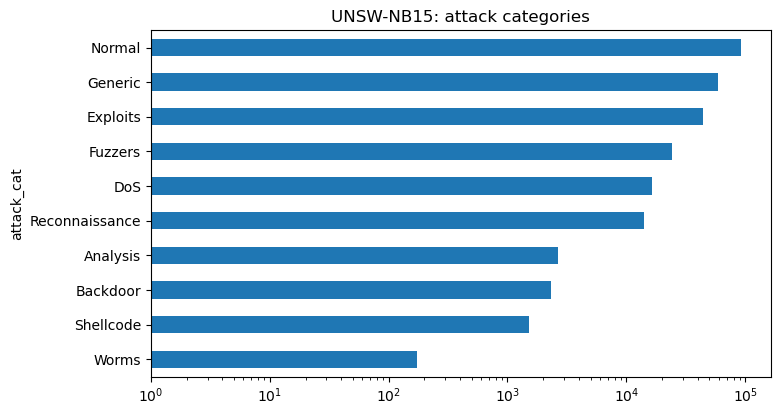

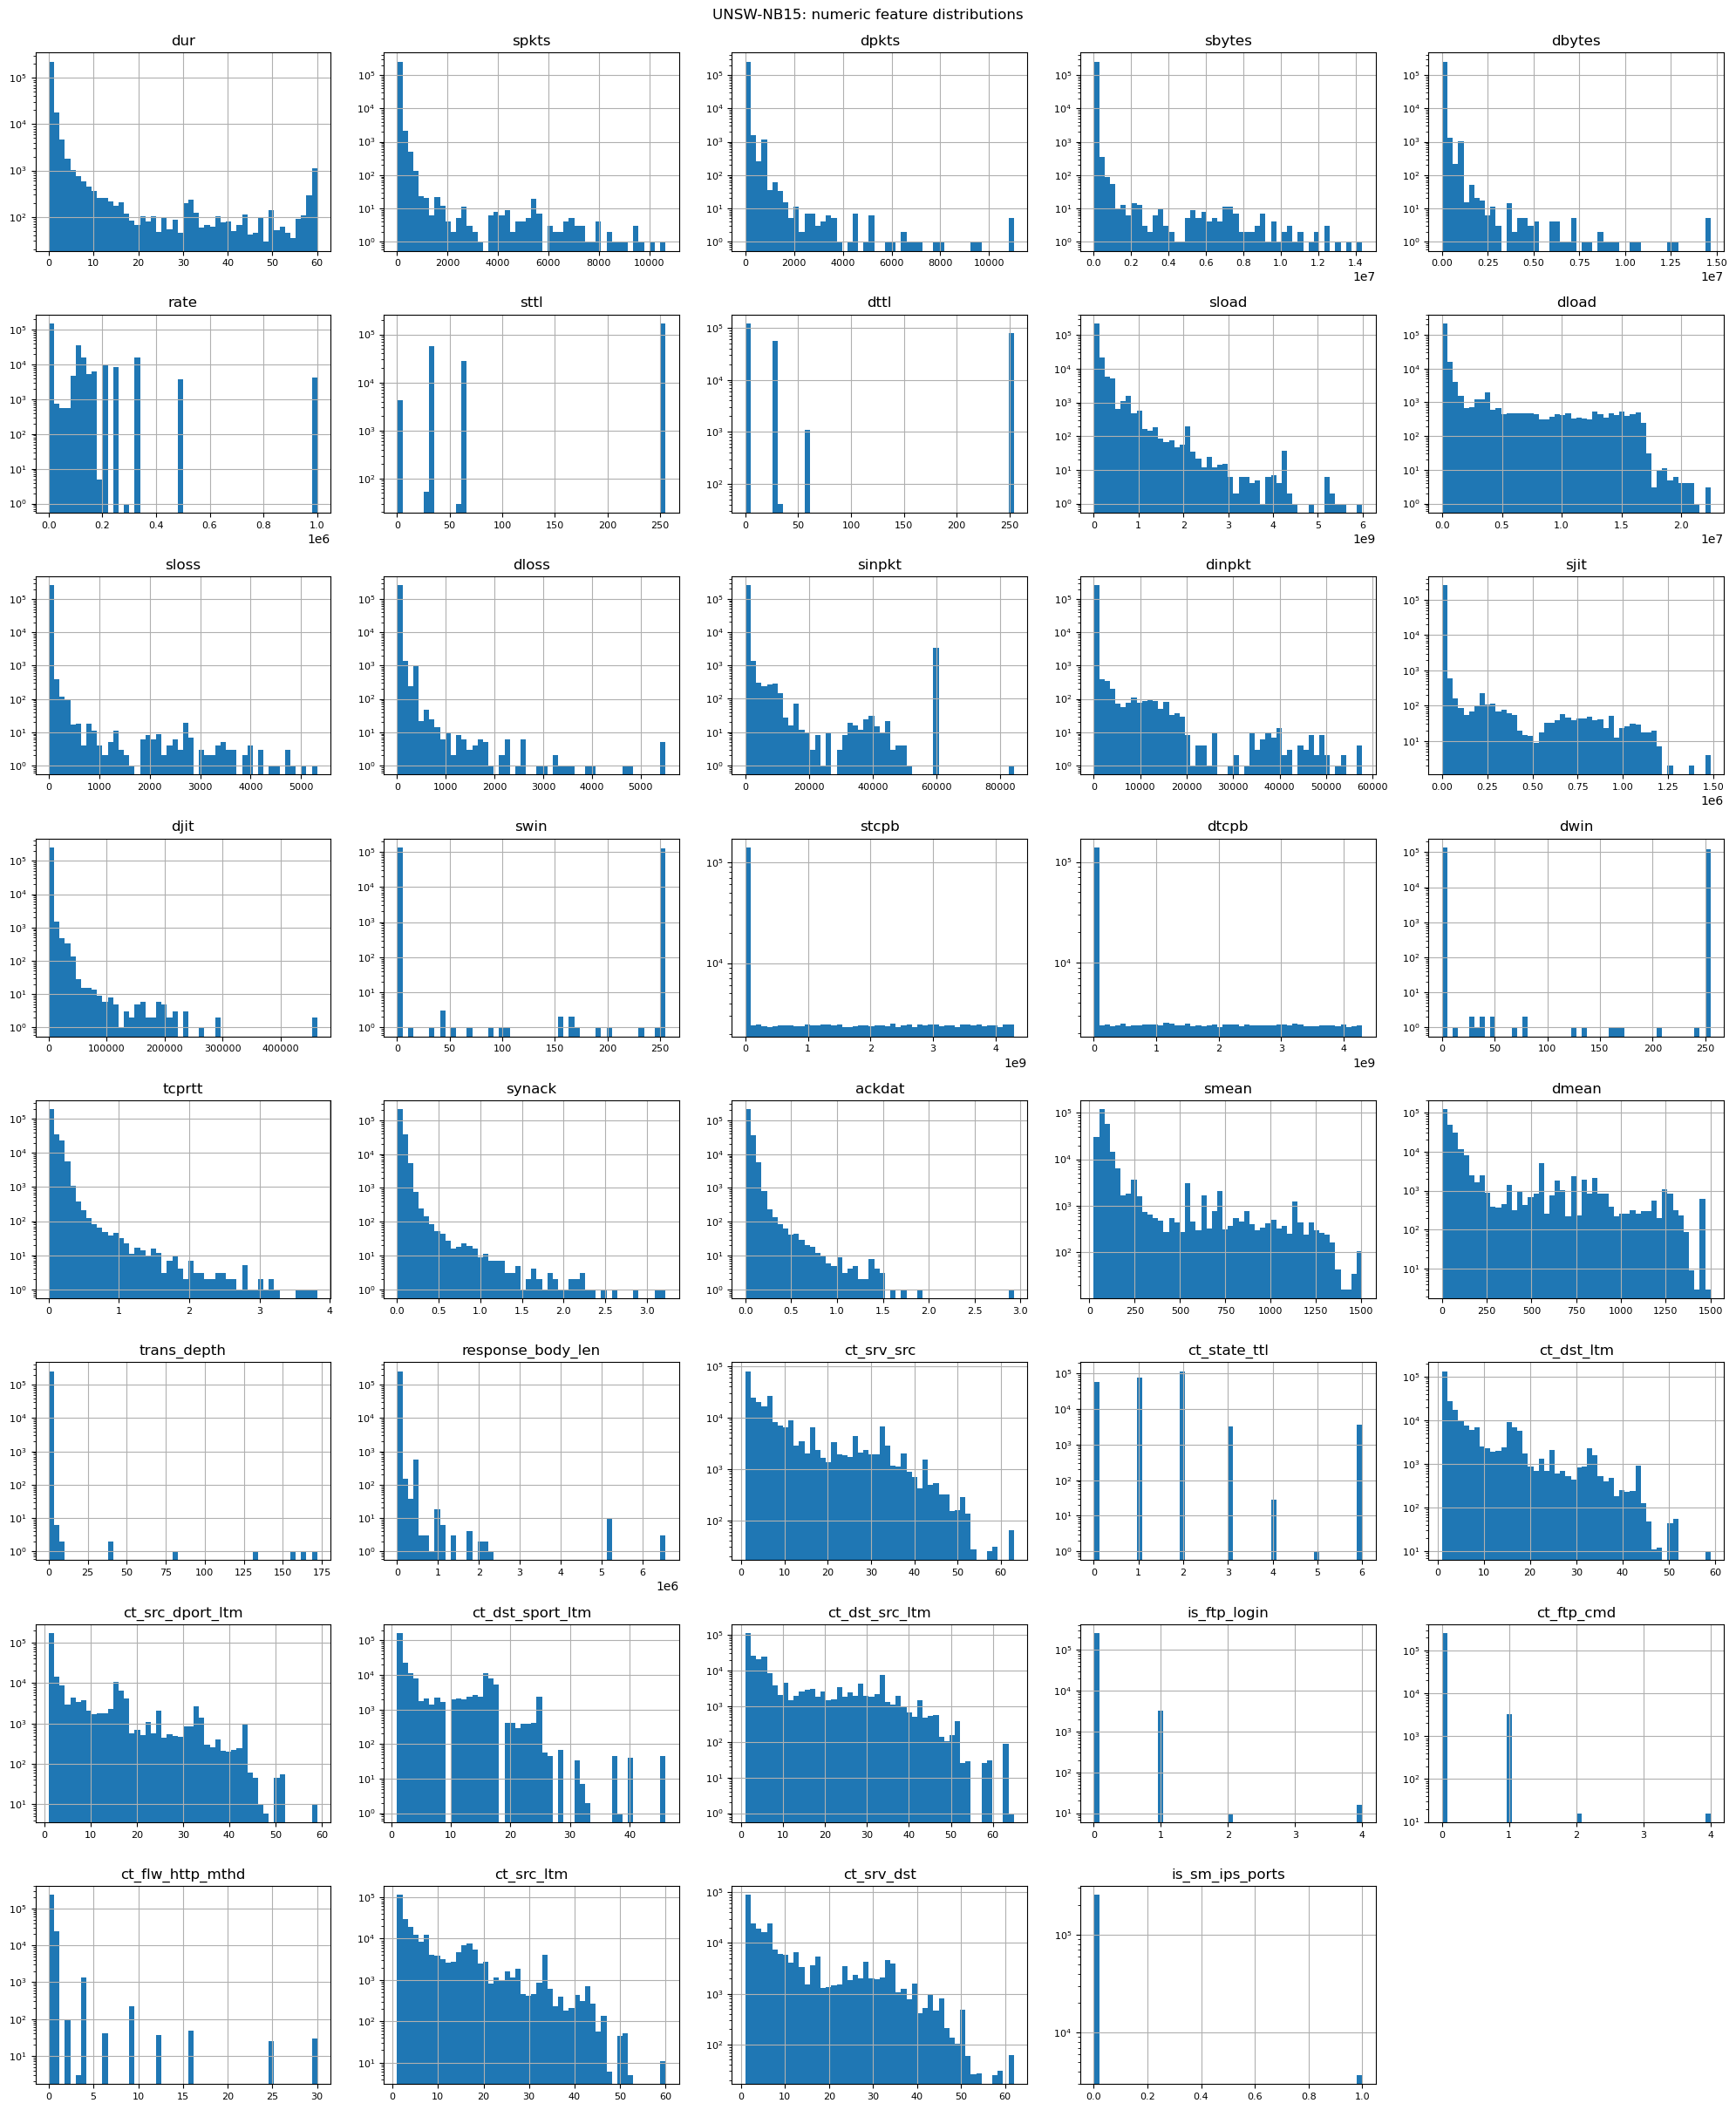

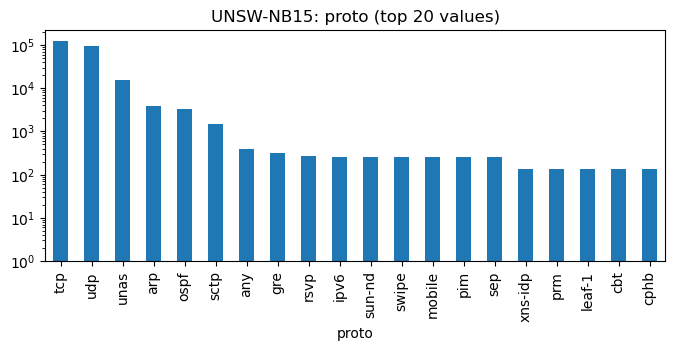

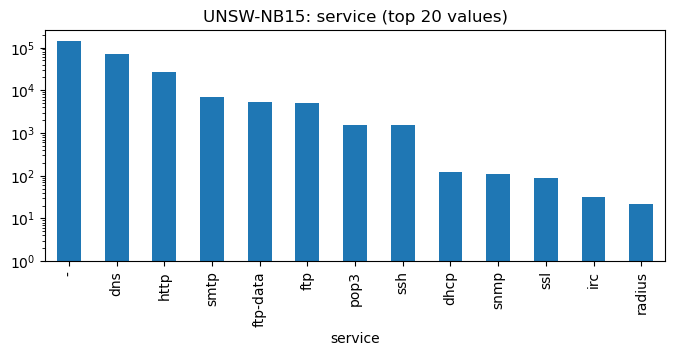

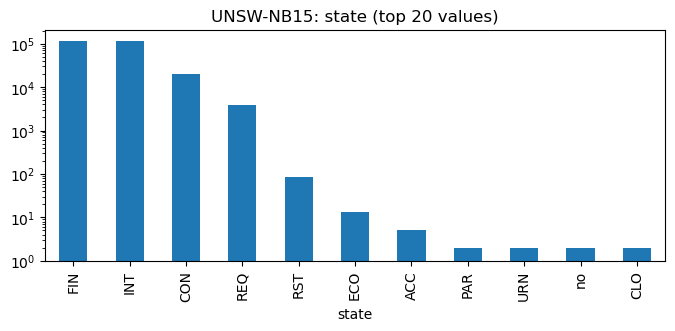

In [5]:
plot_distributions("UNSW-NB15", df)

## CTU-13

In [6]:
df = load_ctu13()
summary["CTU-13"] = report("CTU-13", df)

CTU-13: 10,598,771 rows, 9 features

Benign vs malicious:


,count,%
label,,
Benign,10336198,97.523
Malicious,262573,2.477


Attack categories:


,count,%
attack_cat,,
Background,10133649,95.612
Botnet-Neris,210070,1.982
Normal,202549,1.911
Botnet-Rbot,25142,0.237
Botnet-Virut,21236,0.200
Botnet-Menti,2667,0.025
Botnet-NsisAy,2000,0.019
Botnet-Murlo,1395,0.013
Botnet-Sogou,63,0.001


Feature names (9):
['dur', 'proto', 'dir', 'state', 'stos', 'dtos', 'tot_pkts', 'tot_bytes', 'src_bytes']



,dur,proto,dir,state,stos,dtos,tot_pkts,tot_bytes,src_bytes,attack_cat,label
0,1.026539,tcp,->,S_RA,0.0,0.0,4,276,156,Background,0
1,1.009595,tcp,->,S_RA,0.0,0.0,4,276,156,Background,0
2,3.056586,tcp,->,SR_A,0.0,0.0,3,182,122,Background,0
3,3.111769,tcp,->,SR_A,0.0,0.0,3,182,122,Background,0
4,3.083411,tcp,->,SR_A,0.0,0.0,3,182,122,Background,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10598771 entries, 0 to 10598770
Data columns (total 11 columns):
 #   Column      Non-Null Count     Dtype  
---  ------      --------------     -----  
 0   dur         10598771 non-null  float32
 1   proto       10598771 non-null  object 
 2   dir         10598771 non-null  object 
 3   state       10598695 non-null  object 
 4   stos        10512977 non-null  float32
 5   dtos        9690363 non-null   float32
 6   tot_pkts    10598771 non-null  int32  
 7   tot_bytes   10598771 non-null  int64  
 8   src_bytes   10598771 non-null  int64  
 9   attack_cat  10598771 non-null  object 
 10  label       10598771 non-null  int64  
dtypes: float32(3), int32(1), int64(3), object(4)
memory usage: 727.8+ MB


,count,mean,std,min,25%,50%,75%,max
dur,10598771.0,540.132141,1.077755e+03,0.0,0.005451,0.716635,133.901138,3.657061e+03
stos,10512977.0,0.008292,1.006990e+00,0.0,0.000000,0.000000,0.000000,1.920000e+02
dtos,9690363.0,0.000768,4.455093e-02,0.0,0.000000,0.000000,0.000000,3.000000e+00
tot_pkts,10598771.0,75.893115,7.613475e+03,1.0,2.000000,4.000000,11.000000,1.658064e+07
tot_bytes,10598771.0,60445.353980,5.468097e+06,60.0,266.000000,550.000000,2179.000000,4.376239e+09
src_bytes,10598771.0,12029.091402,2.289821e+06,0.0,81.000000,222.000000,952.000000,3.423408e+09


,count,unique,top,freq
proto,10598771,19,udp,6770160
dir,10598771,7,<->,6278626
state,10598695,455,CON,6271638


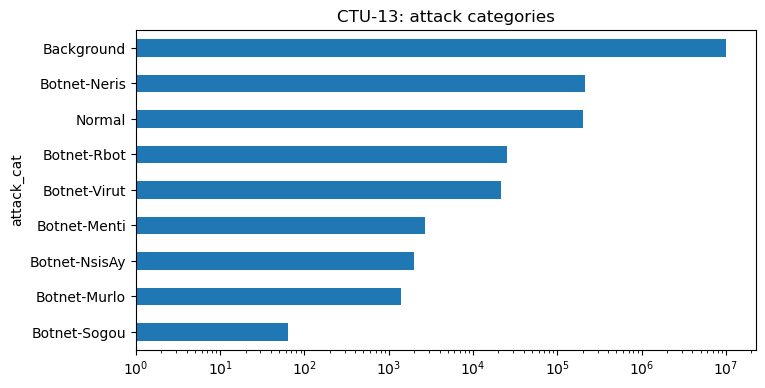

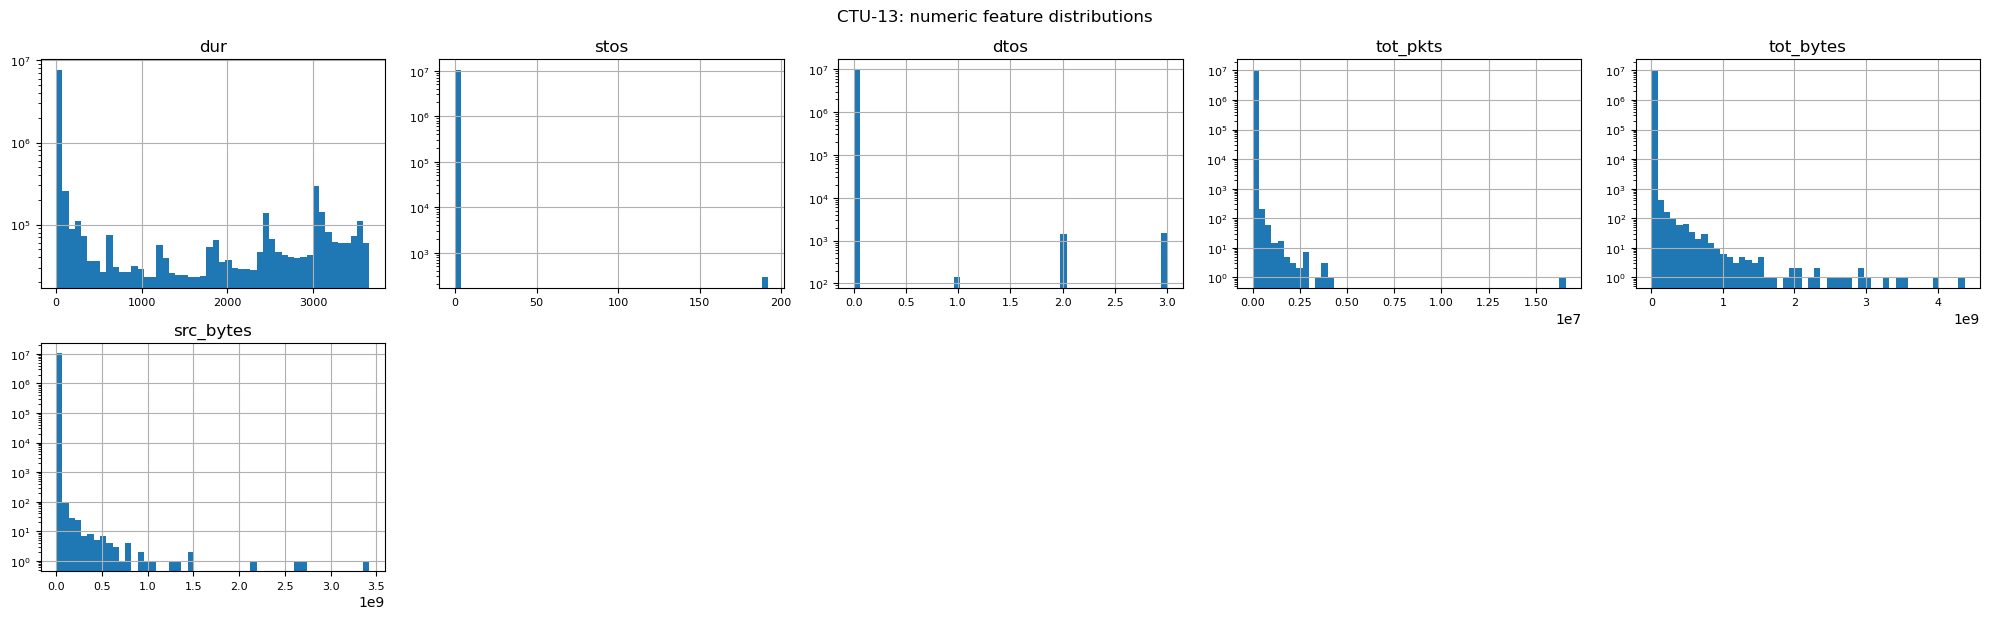

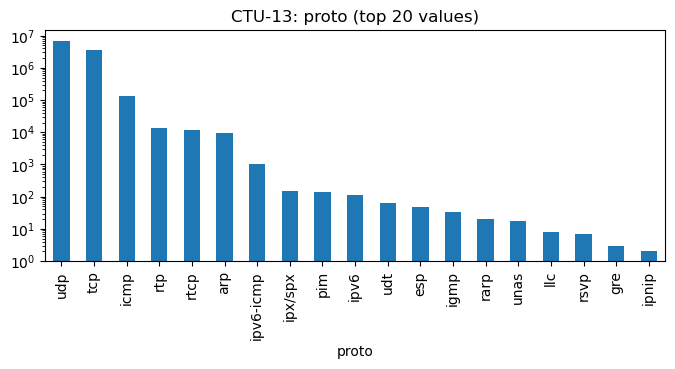

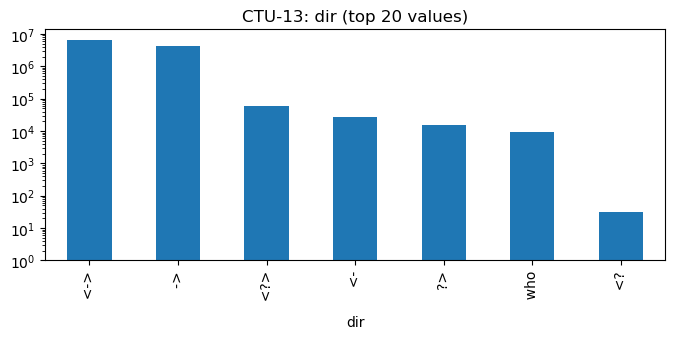

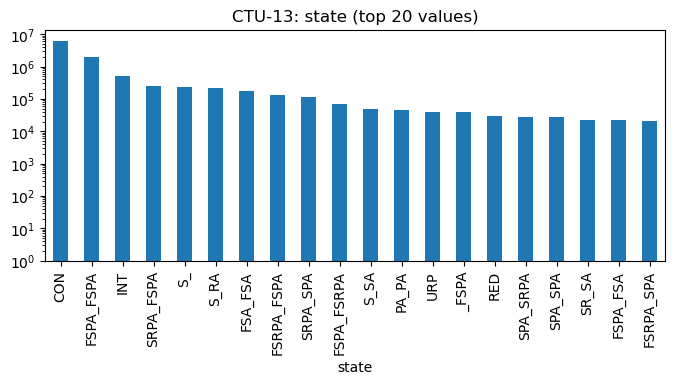

In [7]:
plot_distributions("CTU-13", df)

## CIC-IDS2017

In [8]:
df = load_cicids2017()
summary["CIC-IDS2017"] = report("CIC-IDS2017", df)

CIC-IDS2017: 2,830,743 rows, 78 features

Benign vs malicious:


,count,%
label,,
Benign,2273097,80.3
Malicious,557646,19.7


Attack categories:


,count,%
attack_cat,,
BENIGN,2273097,80.300
DoS Hulk,231073,8.163
PortScan,158930,5.614
DDoS,128027,4.523
DoS GoldenEye,10293,0.364
FTP-Patator,7938,0.280
SSH-Patator,5897,0.208
DoS slowloris,5796,0.205
DoS Slowhttptest,5499,0.194


Feature names (78):
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Cou

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,attack_cat,label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Destination Port             2830743 non-null  int64  
 1   Flow Duration                2830743 non-null  int64  
 2   Total Fwd Packets            2830743 non-null  int64  
 3   Total Backward Packets       2830743 non-null  int64  
 4   Total Length of Fwd Packets  2830743 non-null  int64  
 5   Total Length of Bwd Packets  2830743 non-null  int64  
 6   Fwd Packet Length Max        2830743 non-null  int64  
 7   Fwd Packet Length Min        2830743 non-null  int64  
 8   Fwd Packet Length Mean       2830743 non-null  float64
 9   Fwd Packet Length Std        2830743 non-null  float64
 10  Bwd Packet Length Max        2830743 non-null  int64  
 11  Bwd Packet Length Min        2830743 non-null  int64  
 12  Bwd Packet Length Mean       2830743 non-n

/home/finocchi/conda/miniconda3/envs/lwad_gpu_env/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/finocchi/conda/miniconda3/envs/lwad_gpu_env/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-1.300000e+01,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.000000e+00,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.000000e+00,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.000000e+00,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.000000e+00,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.000000e+00,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.000000e+00,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.000000e+00,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.000000e+00,0.000000,0.000000,2.616295e+01,7.125597e+03


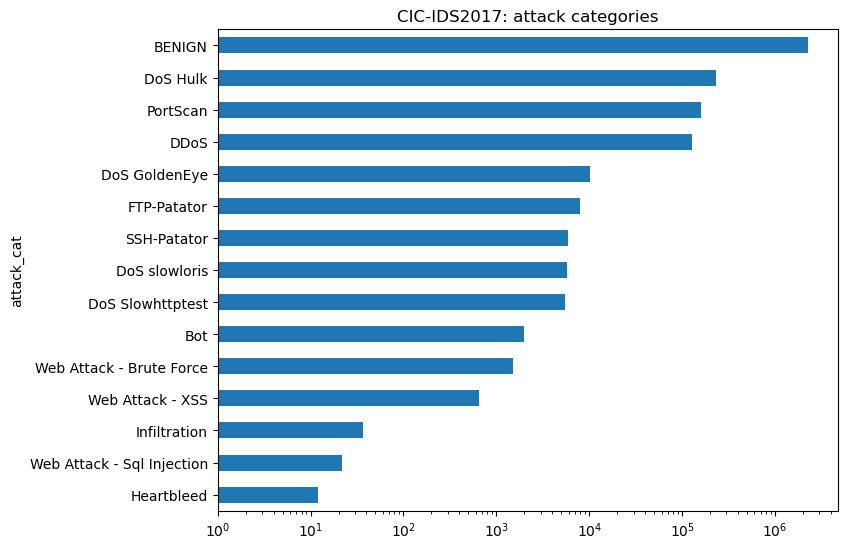

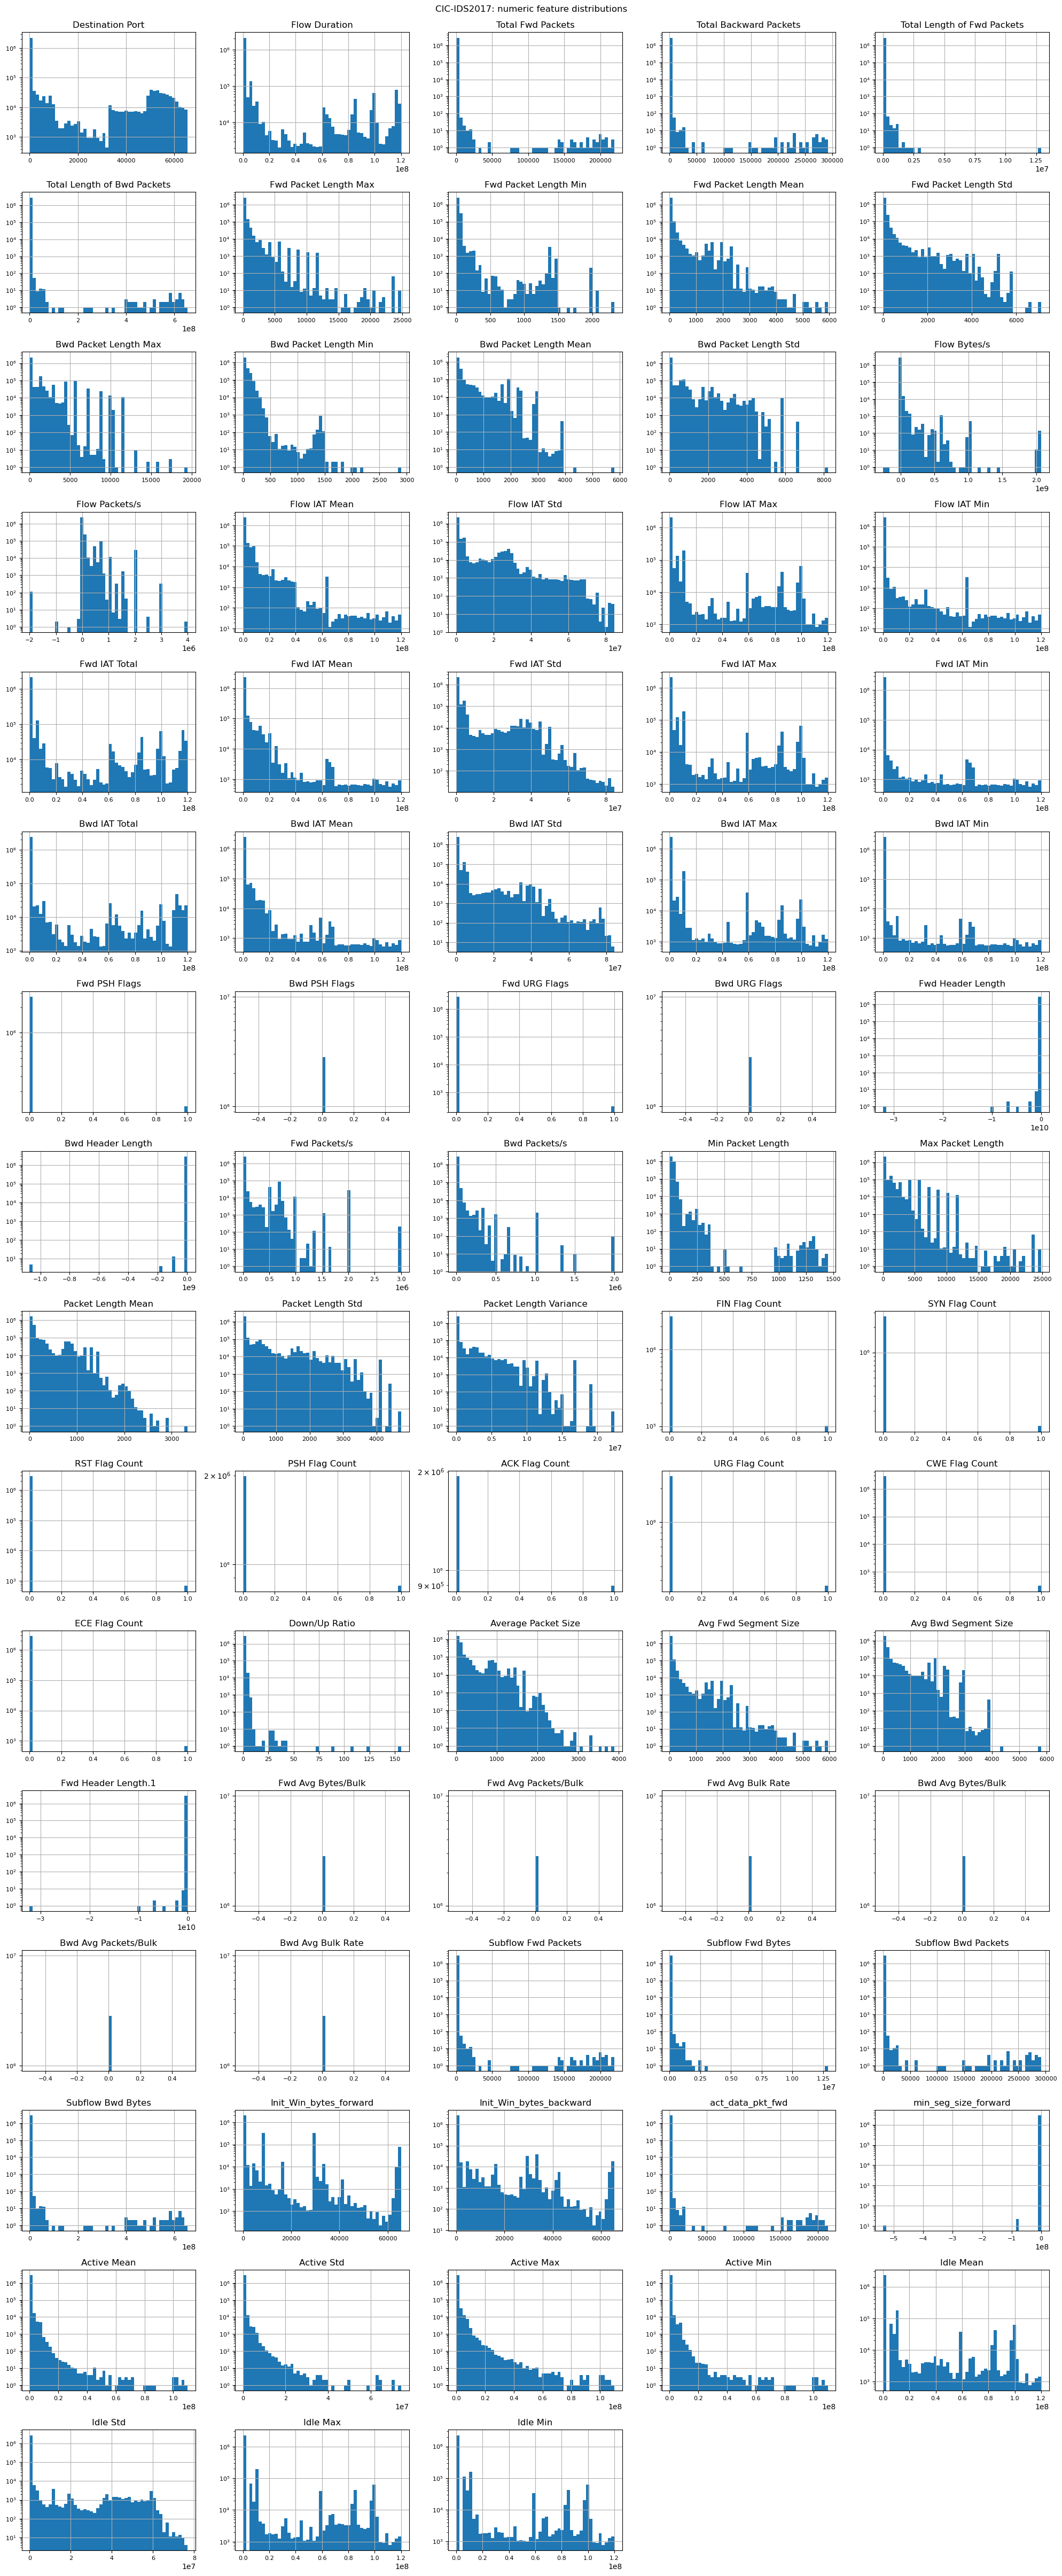

In [9]:
plot_distributions("CIC-IDS2017", df)

## CSE-CIC-IDS2018

In [10]:
df = load_csecicids2018()
summary["CSE-CIC-IDS2018"] = report("CSE-CIC-IDS2018", df)

CSE-CIC-IDS2018: 6,659,532 rows, 77 features

Benign vs malicious:


,count,%
label,,
Benign,5329008,80.021
Malicious,1330524,19.979


Attack categories:


,count,%
attack_cat,,
Benign,5329008,80.021
DDoS attacks-LOIC-HTTP,575364,8.640
DDOS attack-HOIC,198861,2.986
DoS attacks-Hulk,145199,2.180
Bot,144535,2.170
Infilteration,118483,1.779
SSH-Bruteforce,94048,1.412
DoS attacks-GoldenEye,41406,0.622
DoS attacks-Slowloris,9908,0.149


Feature names (77):
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,attack_cat,label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,1460,0,539.000000,655.432922,30597.30523,113.166178,9425.666992,19069.117188,73403.0,1.0,141385.0,17673.125000,23965.324219,73403.0,22.0,51417.0,8569.500000,13036.890625,31525.0,1.0,0,0,0,0,192,152,63.655975,49.510204,0,1460,254.470581,474.712952,225352.390625,0,0,1,1,0,0,0,1,0,270.375000,61.444443,539.000000,0,0,0,0,0,0,9,553,7,3773,8192,119,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,0
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,0,0,0.000000,0.000000,135231.31670,10676.156580,140.500000,174.655380,264.0,17.0,281.0,281.000000,0.000000,281.0,281.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,40,20,7117.437500,3558.718750,0,38,19.000000,21.939310,481.333344,0,1,0,0,1,0,0,0,0,25.333334,19.000000,0.000000,0,0,0,0,0,0,2,38,1,0,123,0,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,0
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,1460,0,701.799988,636.314209,41501.08640,92.915547,11192.959961,24379.449219,112589.0,1.0,279728.0,27972.800781,36167.742188,112589.0,94.0,258924.0,18494.572266,36356.503906,133669.0,1.0,0,0,0,0,232,312,39.310425,53.605122,0,1460,430.111115,566.234192,320621.187500,0,0,1,1,0,0,0,1,1,446.653839,98.727272,701.799988,0,0,0,0,0,0,11,1086,15,10527,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,0
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.00000,15151.515150,132.000000,0.000000,132.0,132.0,132.0,132.000000,0.000000,132.0,132.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,40,0,15151.515625,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,2,0,0,0,256,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,0
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,1460,0,472.384613,611.180481,27100.60726,80.287282,13048.380859,26311.626953,114077.0,1.0,273946.0,34243.250000,37996.566406,114077.0,201.0,252994.0,21082.833984,39075.738281,135611.0,1.0,0,0,0,0,192,272,32.844799,47.442486,0,1460,322.869568,497.254761,247262.296875,0,0,1,1,0,0,0,1,1,337.545441,142.777771,472.384613,0,0,0,0,0,0,9,1285,13,6141,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6659532 entries, 0 to 6659531
Data columns (total 79 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Protocol                  6659532 non-null  int8   
 1   Flow Duration             6659532 non-null  int64  
 2   Total Fwd Packets         6659532 non-null  int32  
 3   Total Backward Packets    6659532 non-null  int32  
 4   Fwd Packets Length Total  6659532 non-null  int32  
 5   Bwd Packets Length Total  6659532 non-null  float64
 6   Fwd Packet Length Max     6659532 non-null  int32  
 7   Fwd Packet Length Min     6659532 non-null  int16  
 8   Fwd Packet Length Mean    6659532 non-null  float32
 9   Fwd Packet Length Std     6659532 non-null  float32
 10  Bwd Packet Length Max     6659532 non-null  int32  
 11  Bwd Packet Length Min     6659532 non-null  int16  
 12  Bwd Packet Length Mean    6659532 non-null  float32
 13  Bwd Packet Length Std     6

,count,mean,std,min,25%,50%,75%,max
Protocol,6659532.0,8.162630e+00,4.544056e+00,0.000000e+00,6.000000,6.000000,6.000000e+00,1.700000e+01
Flow Duration,6659532.0,1.460836e+07,7.704883e+08,-9.190110e+11,8064.000000,695576.000000,5.150532e+06,1.200000e+08
Total Fwd Packets,6659532.0,5.051647e+01,2.373863e+03,1.000000e+00,2.000000,3.000000,7.000000e+00,3.096290e+05
Total Backward Packets,6659532.0,8.055791e+00,1.975216e+02,0.000000e+00,1.000000,2.000000,5.000000e+00,1.231180e+05
Fwd Packets Length Total,6659532.0,1.973359e+03,9.702574e+04,0.000000e+00,20.000000,97.000000,9.350000e+02,1.443918e+08
Bwd Packets Length Total,6659532.0,6.222823e+03,2.806028e+05,0.000000e+00,0.000000,252.000000,9.640000e+02,1.563604e+08
Fwd Packet Length Max,6659532.0,2.958276e+02,3.561090e+02,0.000000e+00,20.000000,82.000000,6.610000e+02,6.444000e+04
Fwd Packet Length Min,6659532.0,9.036304e+00,2.501043e+01,0.000000e+00,0.000000,0.000000,0.000000e+00,1.460000e+03
Fwd Packet Length Mean,6659532.0,6.859879e+01,7.121865e+01,0.000000e+00,6.666667,45.000000,1.086667e+02,1.652931e+04
Fwd Packet Length Std,6659532.0,1.125543e+02,1.443126e+02,0.000000e+00,0.000000,30.599564,1.965220e+02,1.840158e+04


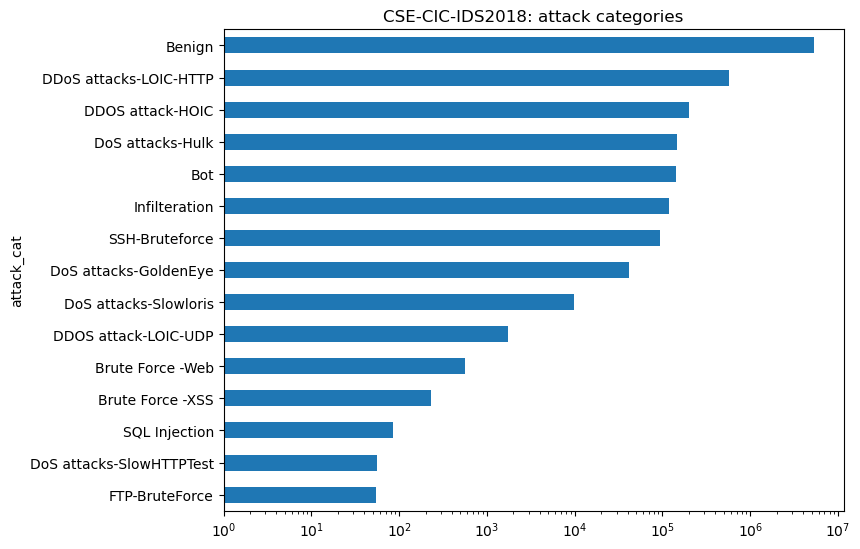

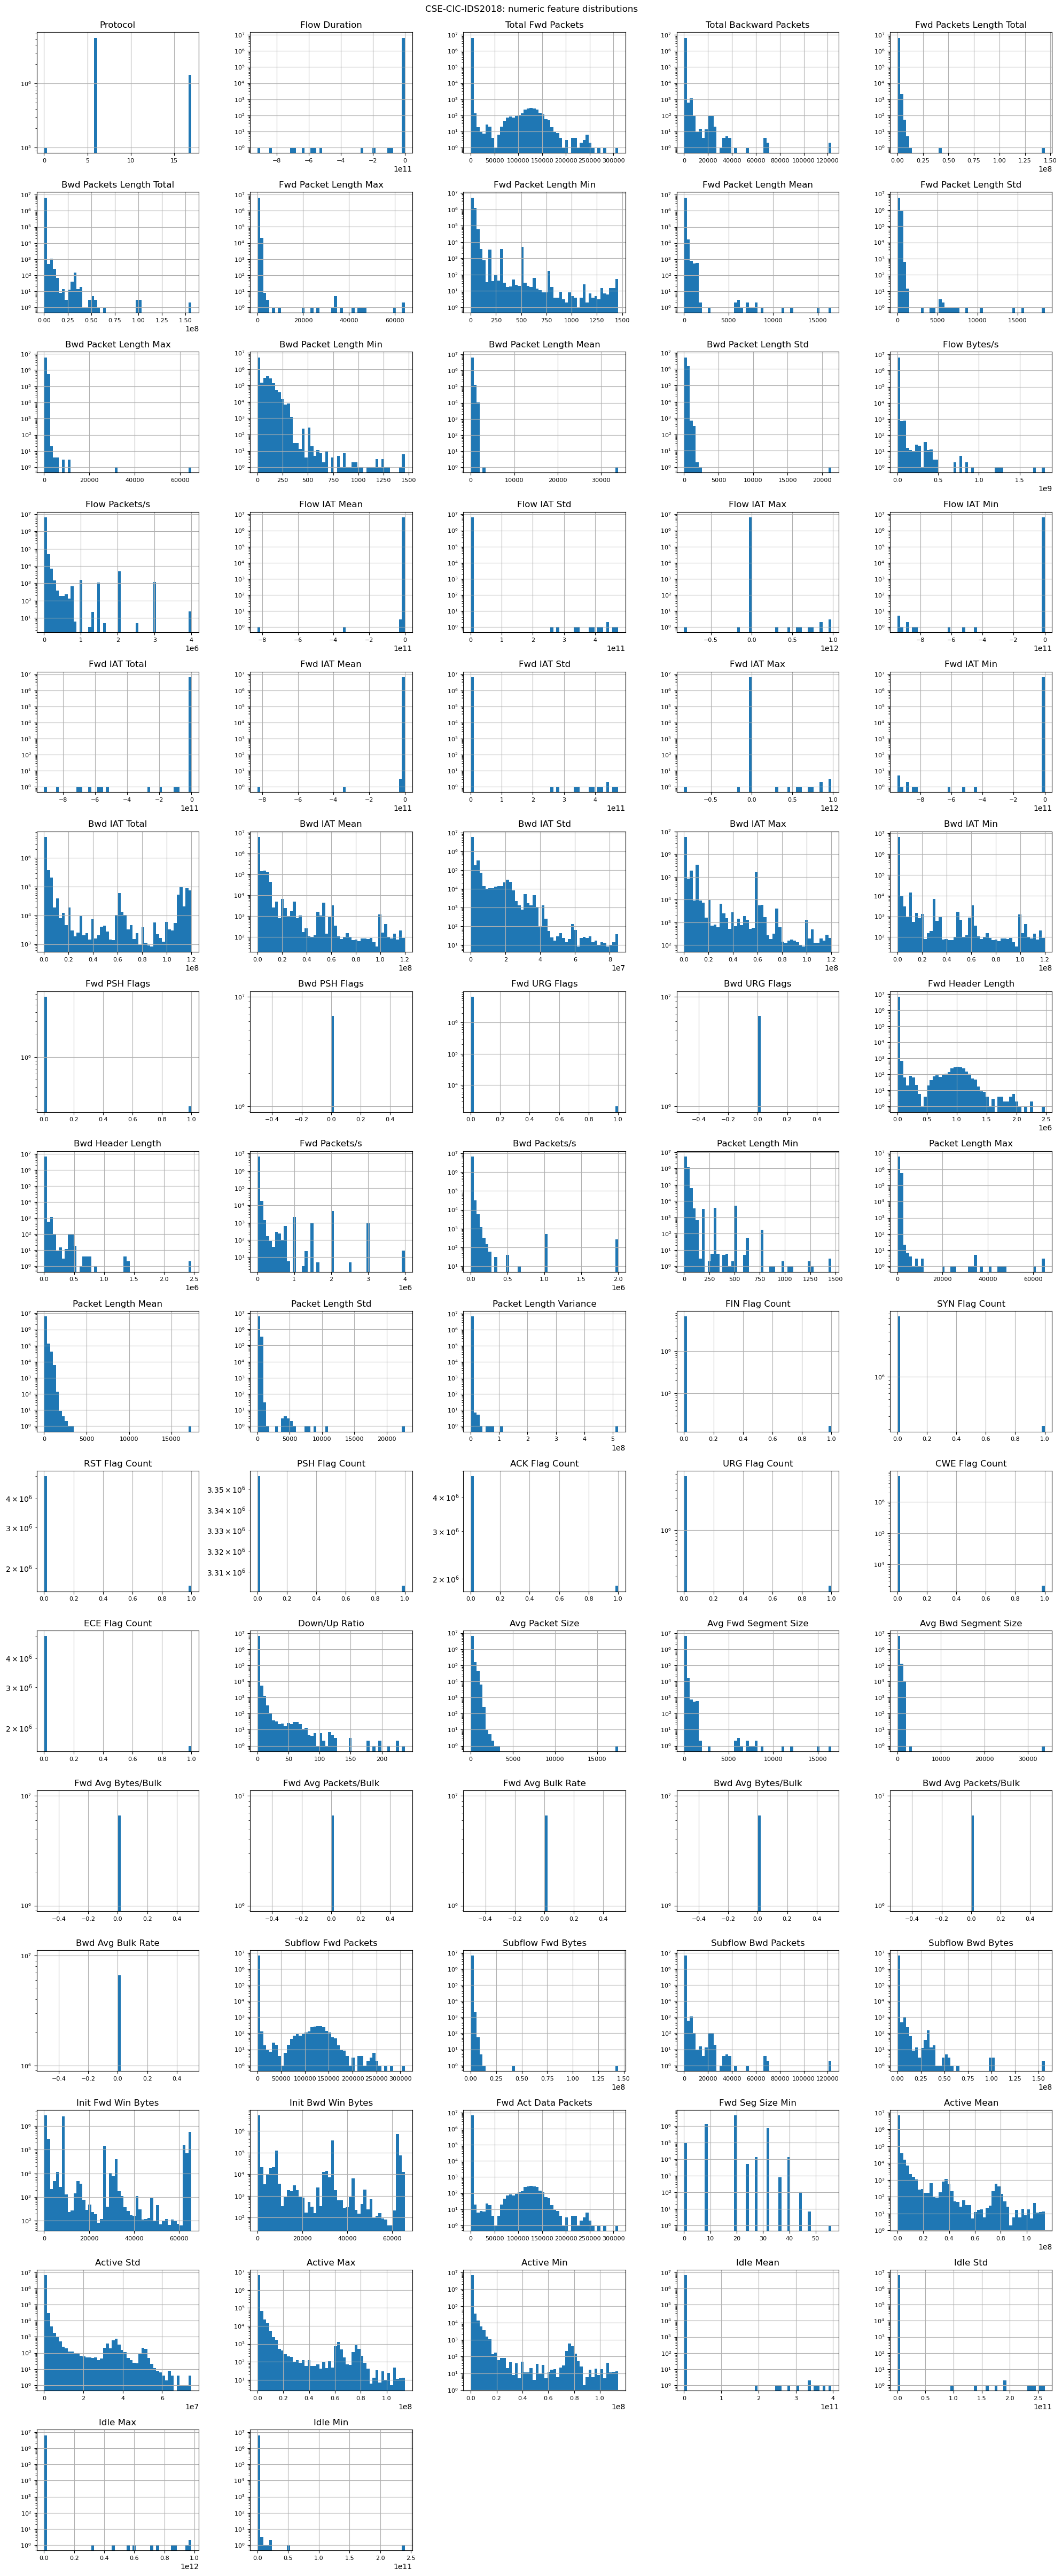

In [11]:
plot_distributions("CSE-CIC-IDS2018", df)

## Summary

In [12]:
pd.DataFrame.from_dict(summary, orient="index")  # keeps the int columns as int

,rows,features,benign %,malicious %,attack categories,missing values,infinite values,duplicate rows
UNSW-NB15,257673,42,36.092,63.908,9,0,0,94928
CTU-13,10598771,9,97.523,2.477,7,994278,0,1147431
CIC-IDS2017,2830743,78,80.300,19.700,14,1358,4376,308381
CSE-CIC-IDS2018,6659532,77,80.021,19.979,14,0,0,339529
